In [ ]:
from panoptica import Panoptica_Statistic
import statistics
from plotly.subplots import make_subplots
import plotly.graph_objects as go

TASKS = ["canalicular vessel", "alpha granule"]
W_MAPS = ['none', 'iw', 'v_region', 'v_size', 'v_mountains', 'v_islands']
LOSSES = ['110', '111']

TASK_MAPPING = {
    "canalicular vessel": "cv",
    "alpha granule": "ag"
}

stats_dict = {}
stats_dict['110'] = {}
stats_dict['111'] = {}


for loss in LOSSES:
    for task in TASKS:
        shorthand = TASK_MAPPING[task]
        stats_dict[loss][shorthand] = {}

        for w_map in W_MAPS:
            file_path = f"logs/{loss}/{task}/{w_map}/version_0/eval.tsv"

            try:
                stats_dict[loss][shorthand][w_map] = Panoptica_Statistic.from_file(
                    file_path)
            except FileNotFoundError:
                print(f"Warning: Could not find file at {file_path}")
                stats_dict[loss][shorthand][w_map] = None

Found 15 entries
Found metrics: ['num_ref_instances', 'num_pred_instances', 'tp', 'fp', 'fn', 'prec', 'rec', 'rq', 'sq_dsc', 'sq_dsc_std', 'pq_dsc', 'sq_assd', 'sq_assd_std', 'sq_cedi', 'sq_cedi_std', 'global_bin_volume_pred', 'global_bin_volume_ref', 'global_bin_dsc']
Found groups: ['instance']
Found 15 entries
Found metrics: ['num_ref_instances', 'num_pred_instances', 'tp', 'fp', 'fn', 'prec', 'rec', 'rq', 'sq_dsc', 'sq_dsc_std', 'pq_dsc', 'sq_assd', 'sq_assd_std', 'sq_cedi', 'sq_cedi_std', 'global_bin_volume_pred', 'global_bin_volume_ref', 'global_bin_dsc']
Found groups: ['instance']
Found 15 entries
Found metrics: ['num_ref_instances', 'num_pred_instances', 'tp', 'fp', 'fn', 'prec', 'rec', 'rq', 'sq_dsc', 'sq_dsc_std', 'pq_dsc', 'sq_assd', 'sq_assd_std', 'sq_cedi', 'sq_cedi_std', 'global_bin_volume_pred', 'global_bin_volume_ref', 'global_bin_dsc']
Found groups: ['instance']
Found 15 entries
Found metrics: ['num_ref_instances', 'num_pred_instances', 'tp', 'fp', 'fn', 'prec', 'rec', 

In [29]:
#stats_dict['110']['cv']['v_region'].print_summary(3, only_across_groups=False)
stats_dict['111']['cv']['none'].get_summary_dict(include_across_group=False)['instance']

{'num_ref_instances': [30.0, 50.0], avg = 38.133 +- 5.34,
 'num_pred_instances': [35.0, 62.0], avg = 43.4 +- 7.228,
 'tp': [29.0, 48.0], avg = 34.533 +- 5.045,
 'fp': [5.0, 18.0], avg = 8.867 +- 3.612,
 'fn': [1.0, 7.0], avg = 3.6 +- 1.497,
 'prec': [0.673, 0.884], avg = 0.8 +- 0.058,
 'rec': [0.837, 0.967], avg = 0.906 +- 0.036,
 'rq': [0.755, 0.905], avg = 0.849 +- 0.043,
 'sq_dsc': [0.78, 0.87], avg = 0.824 +- 0.023,
 'sq_dsc_std': [0.061, 0.201], avg = 0.114 +- 0.039,
 'pq_dsc': [0.625, 0.749], avg = 0.7 +- 0.043,
 'sq_assd': [1.213, 1.881], avg = 1.574 +- 0.215,
 'sq_assd_std': [0.474, 1.569], avg = 0.904 +- 0.335,
 'sq_cedi': [1.109, 2.437], avg = 1.76 +- 0.467,
 'sq_cedi_std': [0.632, 3.093], avg = 1.592 +- 0.811,
 'global_bin_volume_pred': [11809.0, 22616.0], avg = 15366.0 +- 3186.01,
 'global_bin_volume_ref': [12298.0, 21097.0], avg = 16382.067 +- 2925.955,
 'global_bin_dsc': [0.771, 0.846], avg = 0.804 +- 0.022}

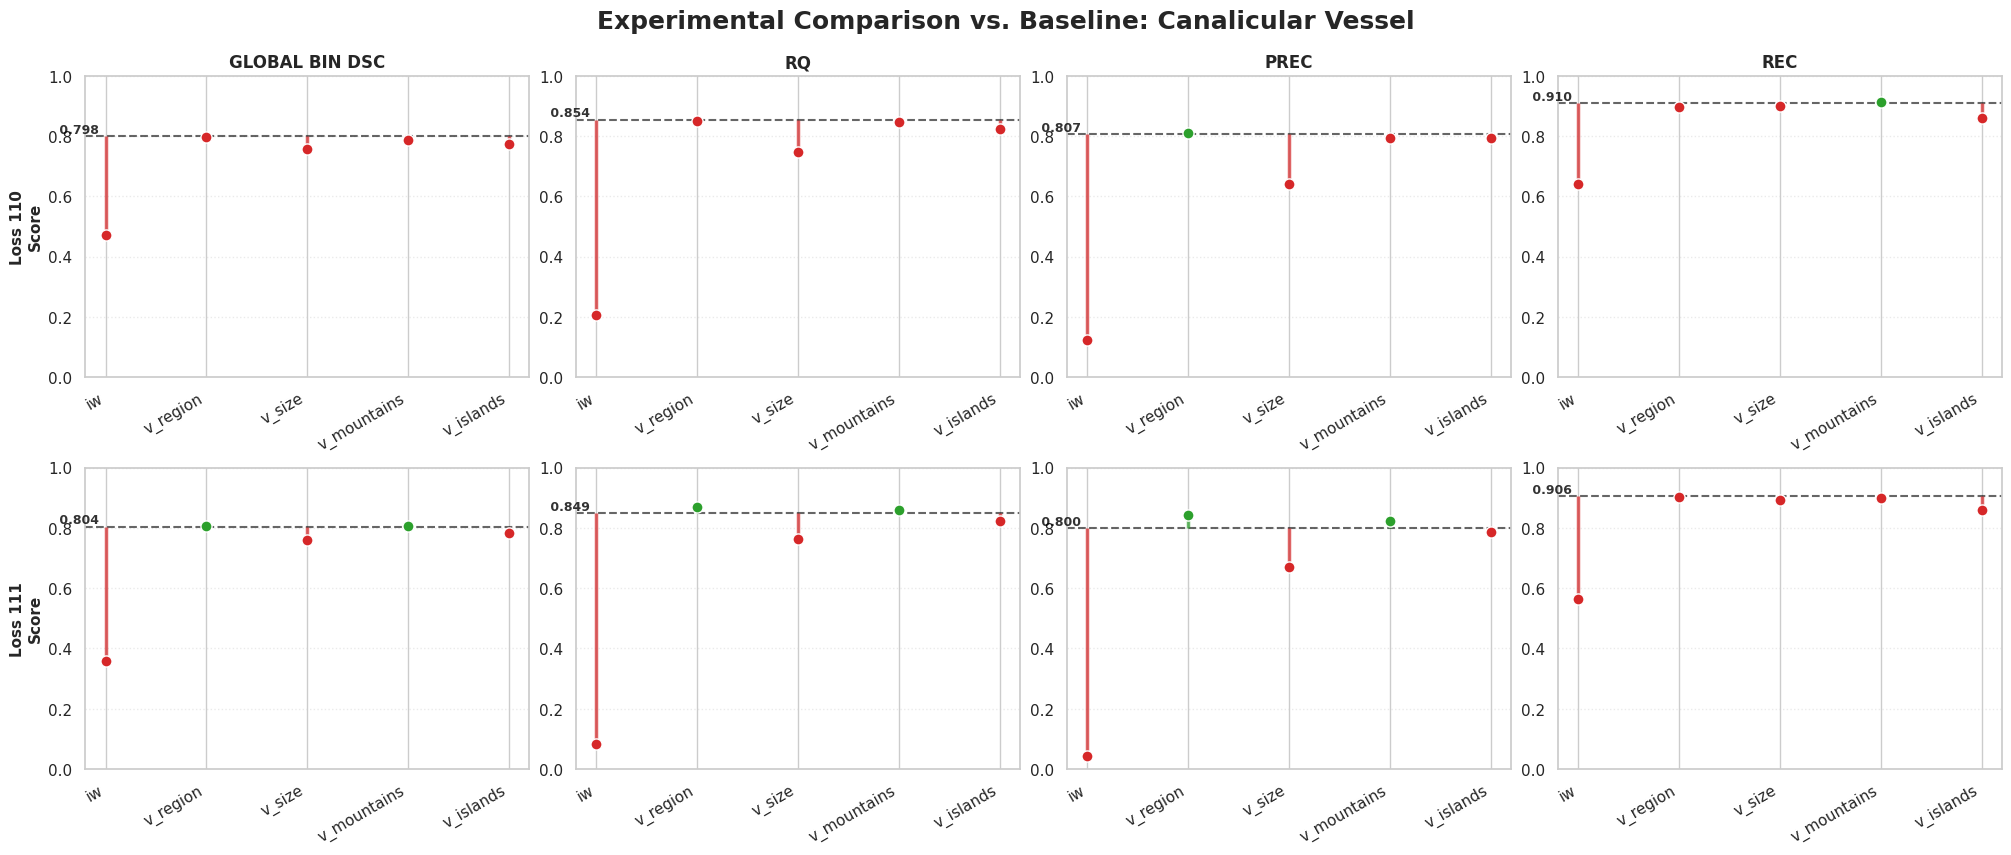

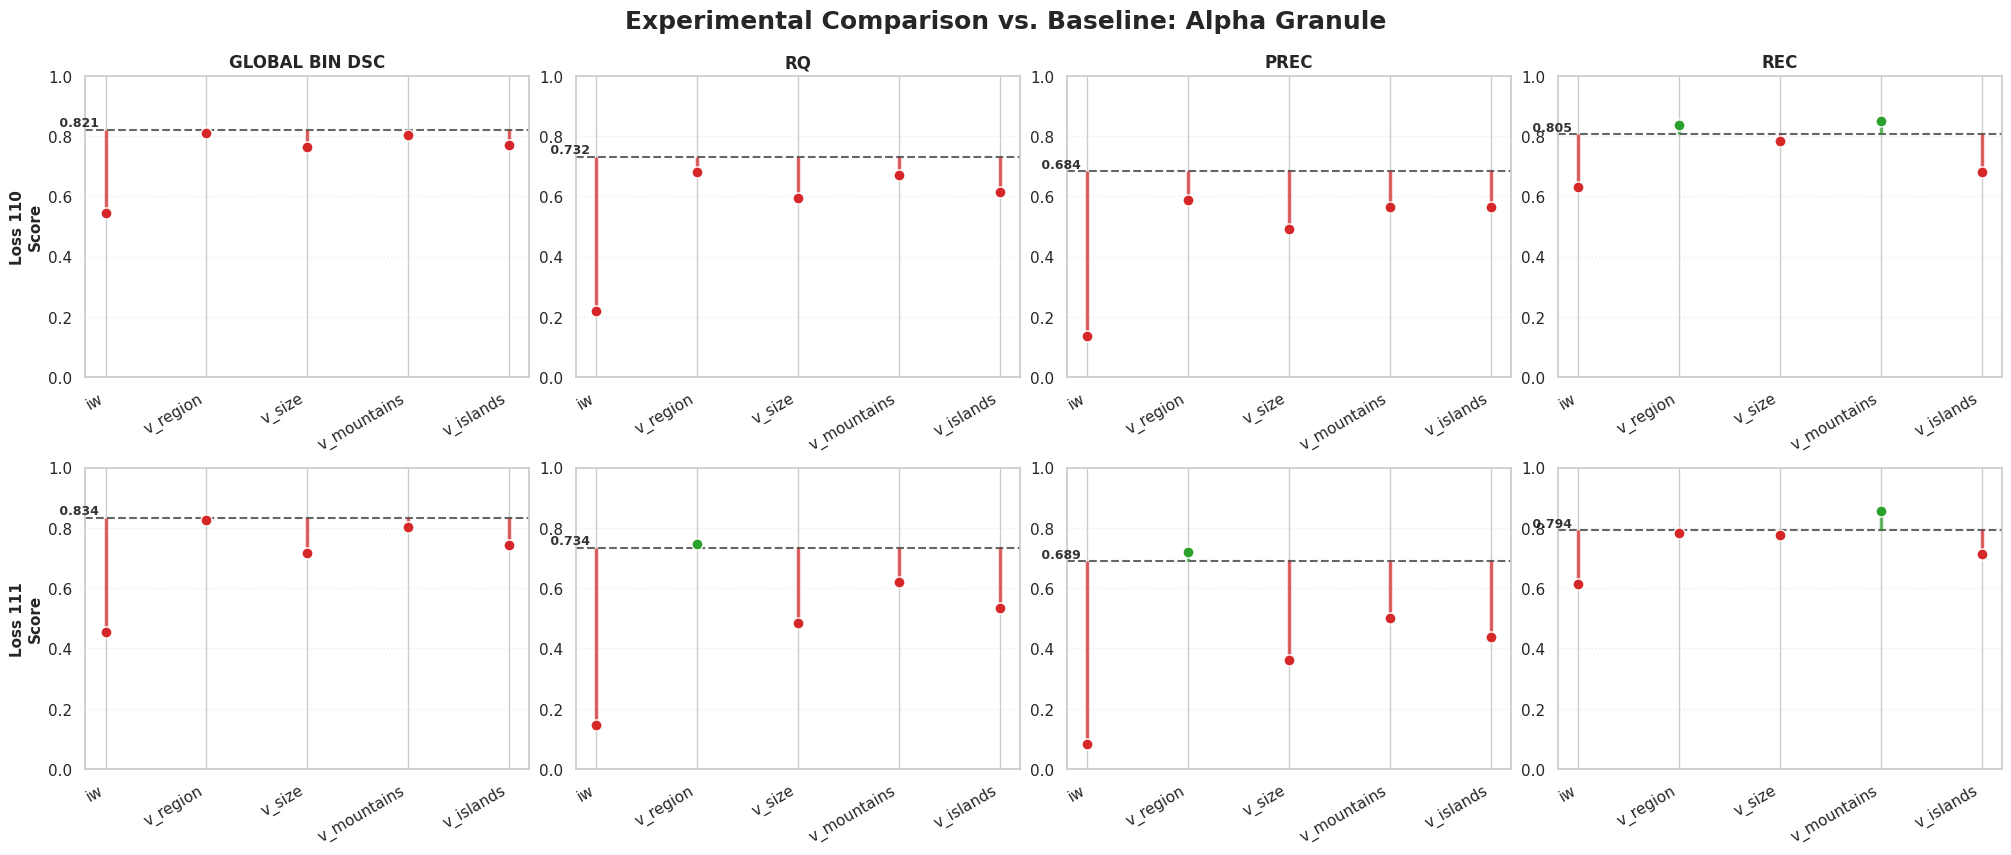

In [ ]:
import matplotlib.pyplot as plt

TASKS_MAPPING = {"canalicular vessel": "cv", "alpha granule": "ag"}
W_MAPS_EXP = ['iw', 'v_region', 'v_size','v_mountains', 'v_islands']
LOSSES = ['110', '111']
METRICS = ['global_bin_dsc', 'rq', 'prec', 'rec']
COLORS = {'improvement': '#2ca02c', 'decline': '#d62728'}

for task_label, task_key in TASKS_MAPPING.items():
    fig, axes = plt.subplots(len(LOSSES), len(
        METRICS), figsize=(20, 8), constrained_layout=True)

    for row_idx, loss in enumerate(LOSSES):
        for col_idx, metric in enumerate(METRICS):
            ax = axes[row_idx, col_idx]

            baseline_val = stats_dict[loss][task_key]['none'].get_summary_dict()[
                'instance'][metric].avg

            ax.axhline(y=baseline_val, color='black', linestyle='--', alpha=0.6)

            ax.text(x=len(W_MAPS_EXP) - 5.5,
                    y=baseline_val, 
                    s=f' {baseline_val:.3f}',
                    va='bottom',
                    ha='left',
                    fontsize=9, 
                    fontweight='bold',
                    color='black',
                    alpha=0.8)

            for x_idx, w_map in enumerate(W_MAPS_EXP):
                val = stats_dict[loss][task_key][w_map].get_summary_dict()[
                    'instance'][metric].avg
                color = COLORS['improvement'] if val >= baseline_val else COLORS['decline']

                ax.vlines(x=x_idx, ymin=min(baseline_val, val), ymax=max(baseline_val, val),
                          color=color, linewidth=2.5, alpha=0.7)
                ax.plot(x_idx, val, marker='o', color=color,
                        markersize=8, markeredgecolor='white')

            if row_idx == 0:
                ax.set_title(metric.replace('_', ' ').upper(),
                             fontsize=12, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(f"Loss {loss}\nScore",
                              fontsize=11, fontweight='bold')

            ax.set_xticks(range(len(W_MAPS_EXP)))
            ax.set_xticklabels(W_MAPS_EXP, rotation=30, ha='right')
            ax.grid(axis='y', linestyle=':', alpha=0.4)

            y_vals = [stats_dict[loss][task_key][w].get_summary_dict(
            )['instance'][metric].avg for w in ['none'] + W_MAPS_EXP]
            ax.set_ylim(0,1)

    plt.suptitle(
        f"Experimental Comparison vs. Baseline: {task_label.title()}", fontsize=18, fontweight='bold', y=1.05)